In [1]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargamos el archivo usando la tercera fila como encabezado

Leads = pd.read_csv("Analisis GAC Full7agosto 2026(Leads Reales).csv",header=2)

In [4]:
Leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [5]:
# Eliminamos espacios sobrantes de los nombres de las columnas

Leads.columns = Leads.columns.str.strip()


# Eliminamos las columnas llamadas unnamed

Leads = Leads.loc[:, ~Leads.columns.str.contains("Unnamed")]


# Mostramos los nombres de las columnas

Leads.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion',
       'Efectividad de Leads'],
      dtype='str')

In [6]:
# Eliminamos los espacios sobrantes de la columna Mes

Leads["Mes"] = Leads["Mes"].astype(str).str.strip()


# Convertimos Año a numérico y completamos los años faltantes

Leads["Año"] = pd.to_numeric(Leads["Año"],errors="coerce").ffill()

In [7]:
# Lista con meses válidos

meses = ["Enero", "Febrero", "Marzo", "Abril","Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]


# Filtramos solamente los registros mensuales

Leads = Leads[Leads["Mes"].isin(meses)]

In [8]:
# Variables numéricas que vamos a categorizar

variables = ["Total", "Efectivos"]

In [9]:
# Convertimos las variables seleccionadas a valores numéricos

for columna in variables:
    Leads[columna] = Leads[columna].astype(str)
    Leads[columna] = Leads[columna].str.replace(",", "")
    Leads[columna] = pd.to_numeric(Leads[columna],errors="coerce")

In [10]:
# Eliminamos los registros que tengan valores nulos

Leads = Leads.dropna(subset=variables)


# Reiniciamos el índice

Leads = Leads.reset_index(drop=True)

In [11]:
# Dimensiones finales de la base

print("Dimensiones:", Leads.shape)


# Valores nulos

Leads[variables].isnull().sum()

Dimensiones: (28, 12)


Total        0
Efectivos    0
dtype: int64

In [12]:
# Número de observaciones

n = len(Leads)

print("Número de observaciones:", n)

Número de observaciones: 28


In [13]:
# Regla de Sturges

ni = 1 + 3.32 * np.log10(n)

print("Número de intervalos sin redondear:", ni)

Número de intervalos sin redondear: 5.8045646640561674


In [14]:
# Redondeamos el resultado de Sturges

numero_intervalos = round(ni)

print("Número de intervalos:", numero_intervalos)

Número de intervalos: 6


In [15]:
# Variable 1: Total

# Límites

Max_Total = Leads["Total"].max()
Min_Total = Leads["Total"].min()

Limites_Total = [Min_Total, Max_Total]

print("Límites de Total:", Limites_Total)

Límites de Total: [np.float64(178.0), np.float64(1973.0)]


In [16]:
# Rango de Total

R_Total = Max_Total - Min_Total

print("Rango de Total:", R_Total)

Rango de Total: 1795.0


In [17]:
# Ancho o amplitud de cada intervalo

i_Total = R_Total / numero_intervalos

print("Amplitud de Total:", i_Total)

Amplitud de Total: 299.1666666666667


In [18]:
# Intervalos para Total

intervalos_Total = np.linspace(177, 1974, 7)

intervalos_Total

array([ 177. ,  476.5,  776. , 1075.5, 1375. , 1674.5, 1974. ])

In [19]:
# Nombres de las categorías de Total

categorias_Total = ["Categoría 1 (177-476.5)", "Categoría 2 (476.5-776)",
                    "Categoría 3 (776-1075.5)", "Categoría 4 (1075.5-1375)",
                    "Categoría 5 (1375-1674.5)", "Categoría 6 (1674.5-1974)"]

In [20]:
# Nueva columna con las categorías de Total

Leads["Categoria Total"] = pd.cut(x=Leads["Total"], bins=intervalos_Total, labels=categorias_Total, include_lowest=True)


# Valores originales y sus categorías

Leads[["Total", "Categoria Total"]]

,Total,Categoria Total
0,543.0,Categoría 2 (476.5-776)
1,178.0,Categoría 1 (177-476.5)
2,416.0,Categoría 1 (177-476.5)
3,422.0,Categoría 1 (177-476.5)
4,967.0,Categoría 3 (776-1075.5)
5,954.0,Categoría 3 (776-1075.5)
6,1409.0,Categoría 5 (1375-1674.5)
7,1315.0,Categoría 4 (1075.5-1375)
8,1973.0,Categoría 6 (1674.5-1974)
9,1562.0,Categoría 5 (1375-1674.5)


In [21]:
# Frecuencia de cada categoría

Tabla_Total = Leads["Categoria Total"].value_counts(sort=False).reset_index()

Tabla_Total

,Categoria Total,count
0,Categoría 1 (177-476.5),3
1,Categoría 2 (476.5-776),2
2,Categoría 3 (776-1075.5),6
3,Categoría 4 (1075.5-1375),9
4,Categoría 5 (1375-1674.5),6
5,Categoría 6 (1674.5-1974),2


In [22]:
# Categorías con frecuencia mayor a cero

Filtro_Total = Tabla_Total[Tabla_Total["count"] > 0]

Filtro_Total

,Categoria Total,count
0,Categoría 1 (177-476.5),3
1,Categoría 2 (476.5-776),2
2,Categoría 3 (776-1075.5),6
3,Categoría 4 (1075.5-1375),9
4,Categoría 5 (1375-1674.5),6
5,Categoría 6 (1674.5-1974),2


In [23]:
# Ajustamos el índice 

Filtro_Total_index = Filtro_Total.set_index("Categoria Total")

Filtro_Total_index

,count
Categoria Total,
Categoría 1 (177-476.5),3
Categoría 2 (476.5-776),2
Categoría 3 (776-1075.5),6
Categoría 4 (1075.5-1375),9
Categoría 5 (1375-1674.5),6
Categoría 6 (1674.5-1974),2


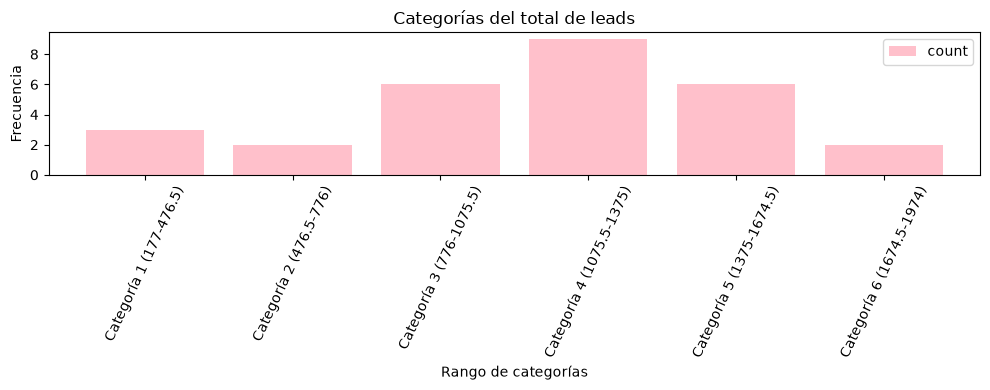

In [37]:
# Gráfica de barras 1: Total

Filtro_Total_index.plot(kind="bar", width=0.8,figsize=(10, 4),color="pink",rot=65)

plt.title("Categorías del total de leads")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [25]:
# Variable 2: Efectivos

# Límites 

Max_Efectivos = Leads["Efectivos"].max()
Min_Efectivos = Leads["Efectivos"].min()

Limites_Efectivos = [Min_Efectivos, Max_Efectivos]

print("Límites de Efectivos:", Limites_Efectivos)

Límites de Efectivos: [np.float64(128.0), np.float64(1040.0)]


In [26]:
# Rango de Efectivos

R_Efectivos = Max_Efectivos - Min_Efectivos

print("Rango de Efectivos:", R_Efectivos)

Rango de Efectivos: 912.0


In [27]:
# Ancho o amplitud de cada intervalo

i_Efectivos = R_Efectivos / numero_intervalos

print("Amplitud de Efectivos:", i_Efectivos)

Amplitud de Efectivos: 152.0


In [28]:
# Intervalos para Efectivos

intervalos_Efectivos = np.linspace(127, 1041, 7)

intervalos_Efectivos

array([ 127.        ,  279.33333333,  431.66666667,  584.        ,
        736.33333333,  888.66666667, 1041.        ])

In [ ]:
# Categorías de Efectivos

categorias_Efectivos = ["Categoría 1 (127-279.33)", "Categoría 2 (279.33-431.67)",
                        "Categoría 3 (431.67-584)", "Categoría 4 (584-736.33)",
                        "Categoría 5 (736.33-888.67)", "Categoría 6 (888.67-1041)"]

In [30]:
# Nueva columna con las categorías de Efectivos

Leads["Categoria Efectivos"] = pd.cut(x=Leads["Efectivos"],bins=intervalos_Efectivos,labels=categorias_Efectivos,include_lowest=True)


# Valores originales y sus categorías

Leads[["Efectivos", "Categoria Efectivos"]]

,Efectivos,Categoria Efectivos
0,389.0,Categoría 2 (279.33-431.67)
1,128.0,Categoría 1 (127-279.33)
2,288.0,Categoría 2 (279.33-431.67)
3,274.0,Categoría 1 (127-279.33)
4,620.0,Categoría 4 (584-736.33)
5,570.0,Categoría 3 (431.67-584)
6,546.0,Categoría 3 (431.67-584)
7,530.0,Categoría 3 (431.67-584)
8,822.0,Categoría 5 (736.33-888.67)
9,1040.0,Categoría 6 (888.67-1041)


In [31]:
# Frecuencia de cada categoría

Tabla_Efectivos = Leads["Categoria Efectivos"].value_counts(sort=False).reset_index()

Tabla_Efectivos

,Categoria Efectivos,count
0,Categoría 1 (127-279.33),2
1,Categoría 2 (279.33-431.67),2
2,Categoría 3 (431.67-584),5
3,Categoría 4 (584-736.33),12
4,Categoría 5 (736.33-888.67),3
5,Categoría 6 (888.67-1041),4


In [32]:
# Categorías con frecuencia mayor a cero

Filtro_Efectivos = Tabla_Efectivos[Tabla_Efectivos["count"] > 0]

Filtro_Efectivos

,Categoria Efectivos,count
0,Categoría 1 (127-279.33),2
1,Categoría 2 (279.33-431.67),2
2,Categoría 3 (431.67-584),5
3,Categoría 4 (584-736.33),12
4,Categoría 5 (736.33-888.67),3
5,Categoría 6 (888.67-1041),4


In [33]:
# Ajustamos el índice 

Filtro_Efectivos_index = Filtro_Efectivos.set_index("Categoria Efectivos")

Filtro_Efectivos_index

,count
Categoria Efectivos,
Categoría 1 (127-279.33),2
Categoría 2 (279.33-431.67),2
Categoría 3 (431.67-584),5
Categoría 4 (584-736.33),12
Categoría 5 (736.33-888.67),3
Categoría 6 (888.67-1041),4


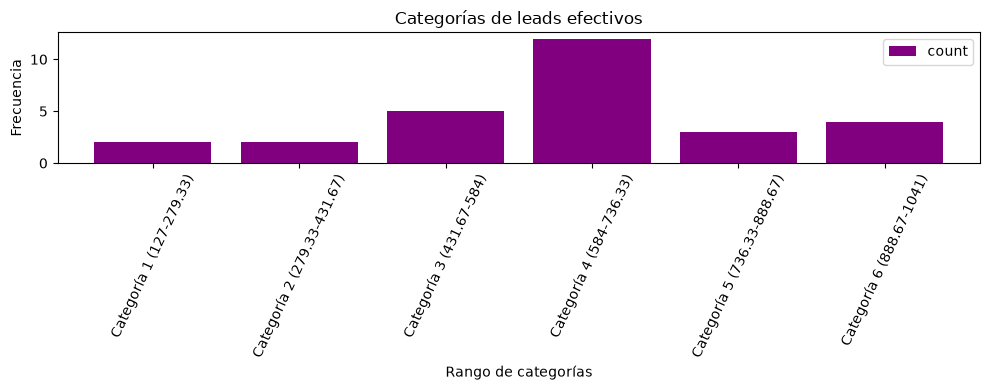

In [35]:
# Gráfica de barras 2: Efectivos

Filtro_Efectivos_index.plot(kind="bar", width=0.8, figsize=(10, 4), color="purple",rot=65)

plt.title("Categorías de leads efectivos")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()